In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [2]:
from google.colab import files
uploaded = files.upload()

Saving university_admission.csv to university_admission.csv


In [3]:
df = pd.read_csv(io.BytesIO(uploaded['university_admission.csv']))

In [4]:
df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [7]:
df.isnull().sum()

,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admission,0


In [8]:
df.describe()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


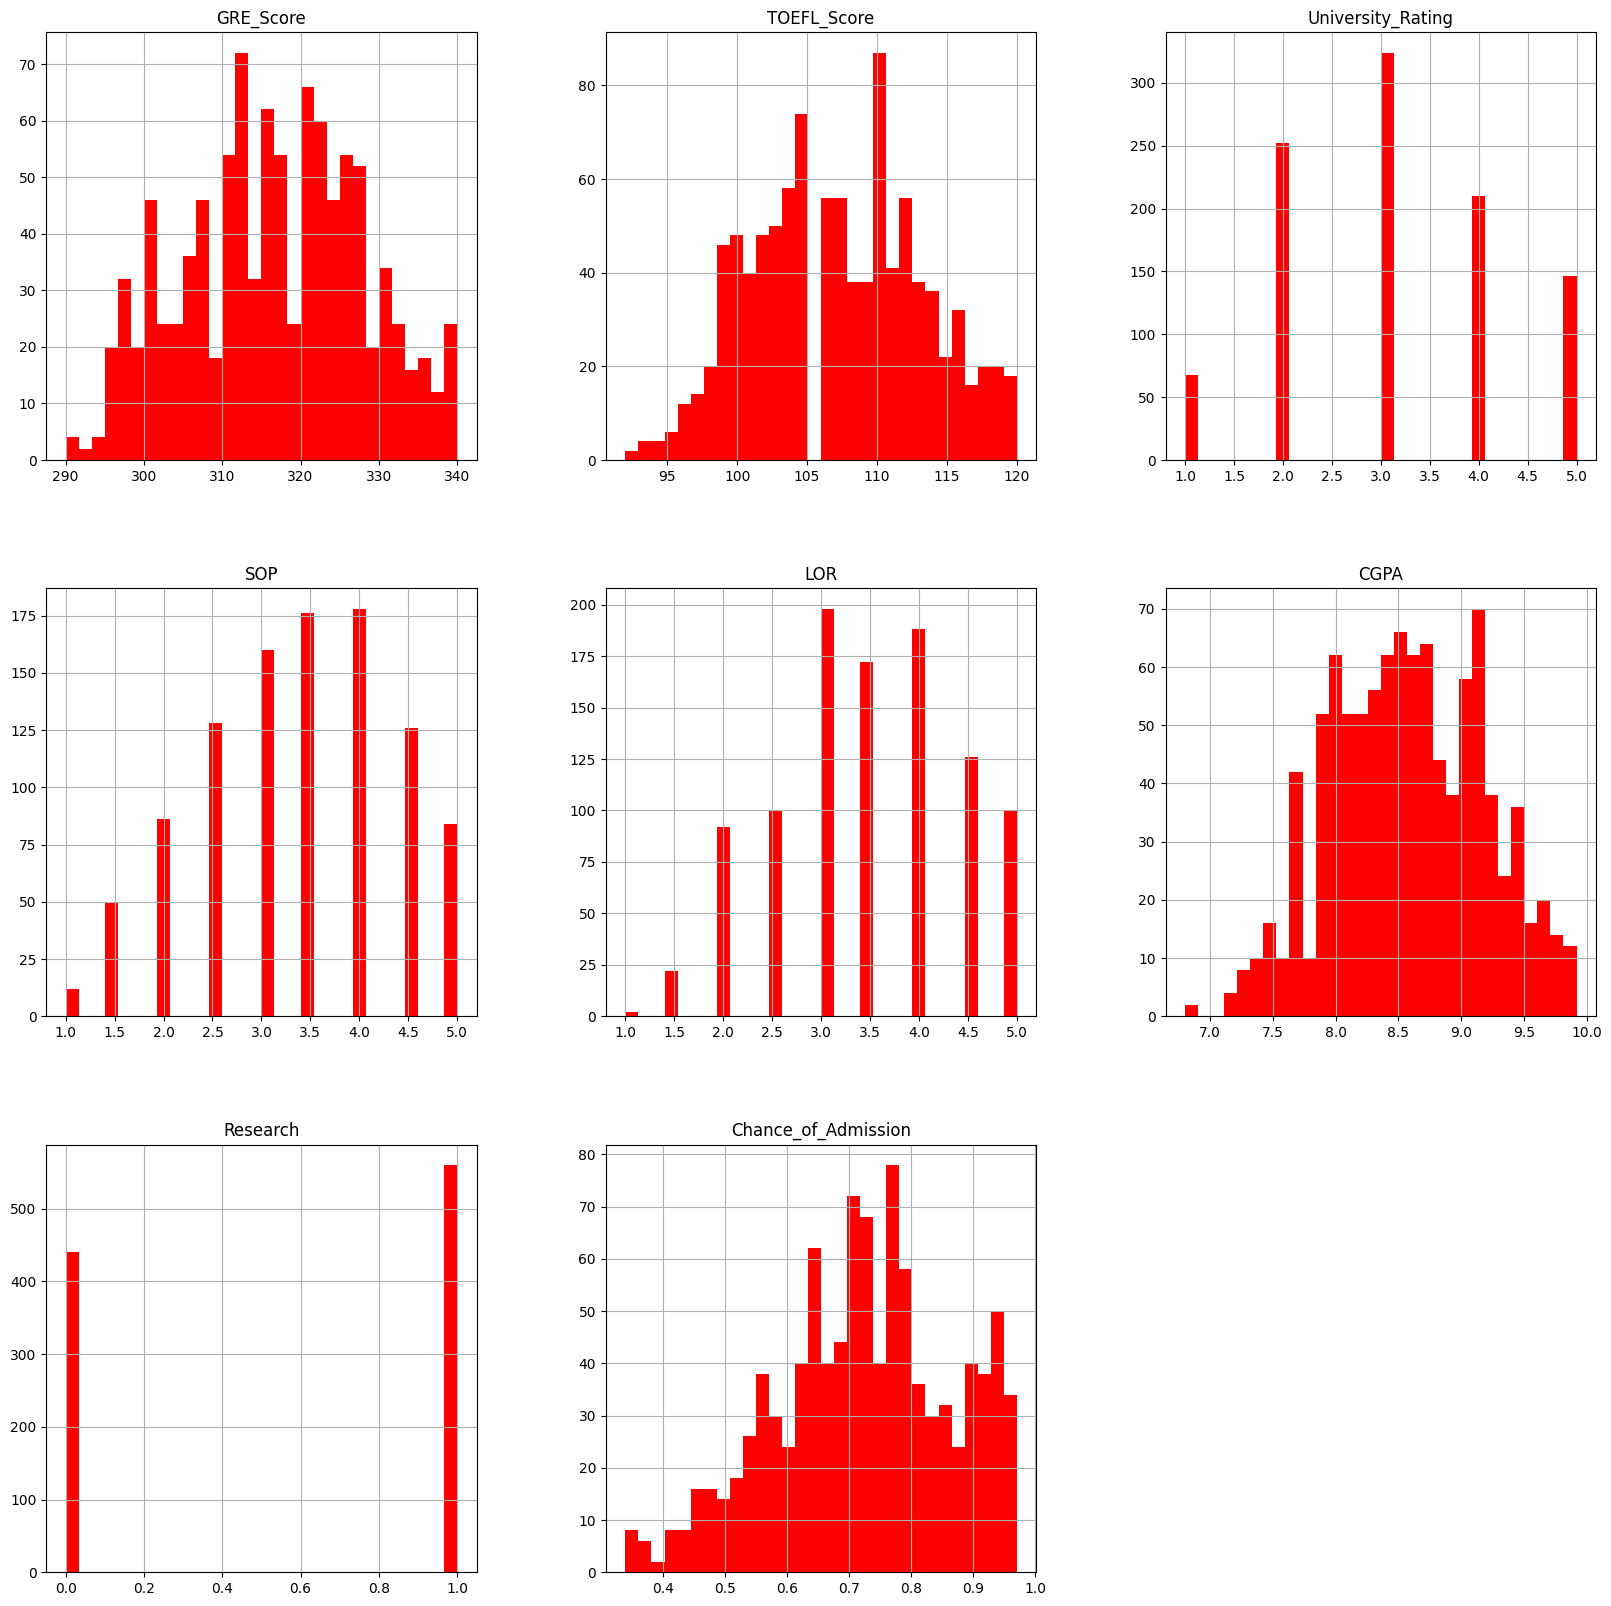

In [9]:
df.hist(bins = 30, figsize = (20,20), color = 'r')
plt.show()

<Axes: >

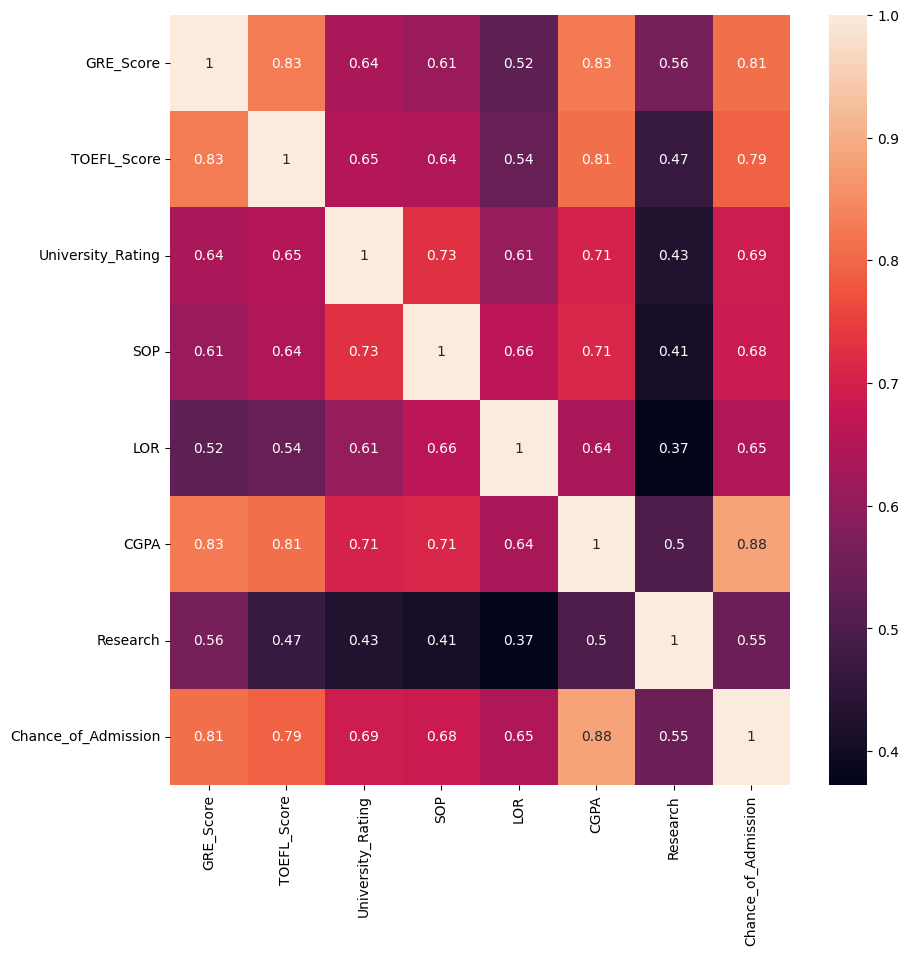

In [14]:
corr_mat = df.corr()
plt.figure(figsize = (10,10))
sns.heatmap(corr_mat,annot = True)

In [27]:
y = df['Chance_of_Admission']
x = df.drop(columns = 'Chance_of_Admission')

In [28]:
x = np.array(x).astype('float32')
y = np.array(y).astype('float32')

In [29]:
x.shape

(1000, 7)

In [30]:
y.shape

(1000,)

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3)

In [32]:
x_train.shape

(700, 7)

In [33]:
y_train.shape

(700,)

In [34]:
x_test.shape

(300, 7)

In [35]:
y_test.shape

(300,)

In [36]:
from xgboost import XGBRegressor

In [60]:
model = XGBRegressor(objective = 'reg:squarederror',learning_rate = 0.1, max_depth = 30, n_estimators = 100)
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=30,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
result = model.score(x_test,y_test)
print("R2 score: ",result)

R2 score:  0.9262831211090088


In [72]:
y_pred = model.predict(x_test)

In [73]:
MRE = np.mean(((y_test - y_pred)/y_pred))
print("Mean relative error: ",MRE)

Mean relative error:  0.0012647195


In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from math import sqrt

MAE = mean_absolute_error(y_test,y_pred)
RMSE = sqrt(mean_squared_error(y_test,y_pred))
R2 = r2_score(y_test,y_pred)

k = x_test.shape[1]
n = y_test.shape[0]

adj_R2 = 1 - ((1-R2)*(n-1)/(n-k-1))

print("MAE = ",MAE)
print("RMSE = ",RMSE)
print("R2 = ", R2)
print("adjusted R2 = ", adj_R2)

MAE =  0.013512460514903069
RMSE =  0.037143428135818404
R2 =  0.9262831211090088
adjusted R2 =  0.9245159356561425


In [84]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [85]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))

st.title("University Admission Predictor")

gre = st.number_input("GRE Score", 260, 340)
toefl = st.number_input("TOEFL Score", 0, 120)
rating = st.slider("University Rating", 1, 5)
sop = st.slider("SOP Strength", 1.0, 5.0)
lor = st.slider("LOR Strength", 1.0, 5.0)
cgpa = st.number_input("CGPA (out of 10)", 0.0, 10.0)
research = st.selectbox("Research Experience", [0, 1])

if st.button("Predict"):
    input_data = np.array([[gre, toefl, rating, sop, lor, cgpa, research]])
    prediction = model.predict(input_data)[0]
    st.success(f"Chance of Admission: {prediction*100:.2f}%")

Writing app.py


In [87]:
files.download("app.py")
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>